✅ Dataset downloaded!
✅ Data ready | Train: (125973, 41) | Test: (22544, 41)
✅ Naïve Bayes Training complete!

  NAÏVE BAYES RESULTS
  Accuracy  : 0.7714
  Precision : 0.9113
  Recall    : 0.6629
  F1-Score  : 0.7675
              precision    recall  f1-score   support

      Normal       0.67      0.91      0.78      9711
      Attack       0.91      0.66      0.77     12833

    accuracy                           0.77     22544
   macro avg       0.79      0.79      0.77     22544
weighted avg       0.81      0.77      0.77     22544



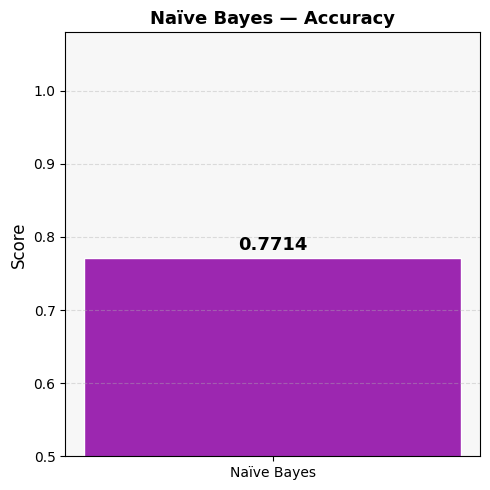

✅ Plot 1 saved


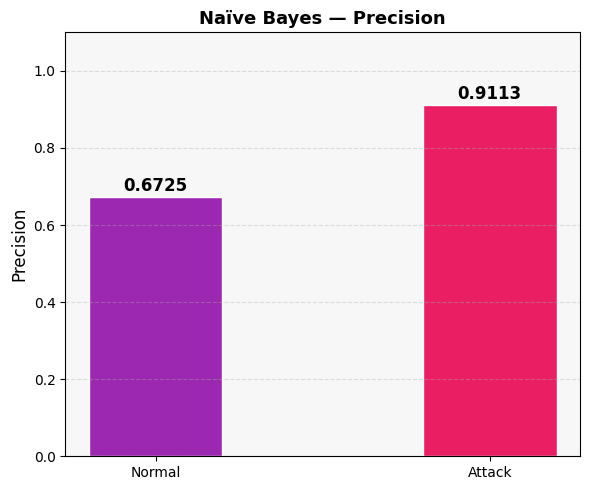

✅ Plot 2 saved


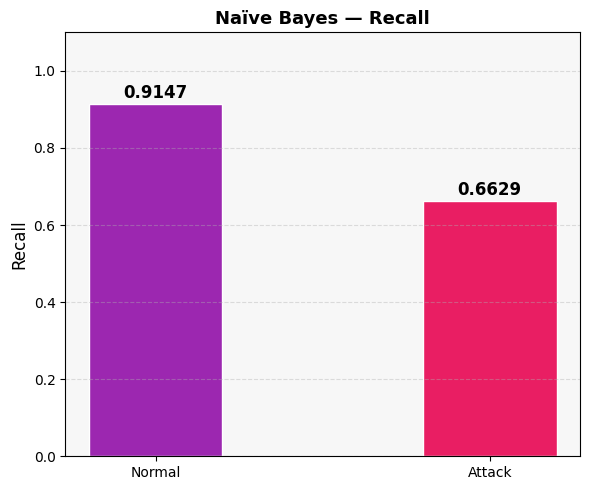

✅ Plot 3 saved


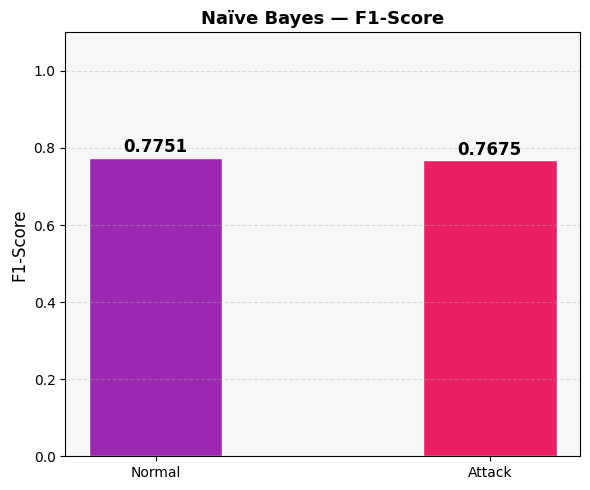

✅ Plot 4 saved


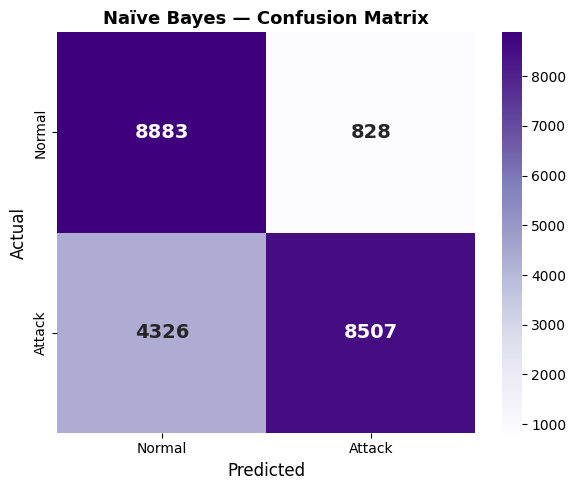

✅ Plot 5 saved


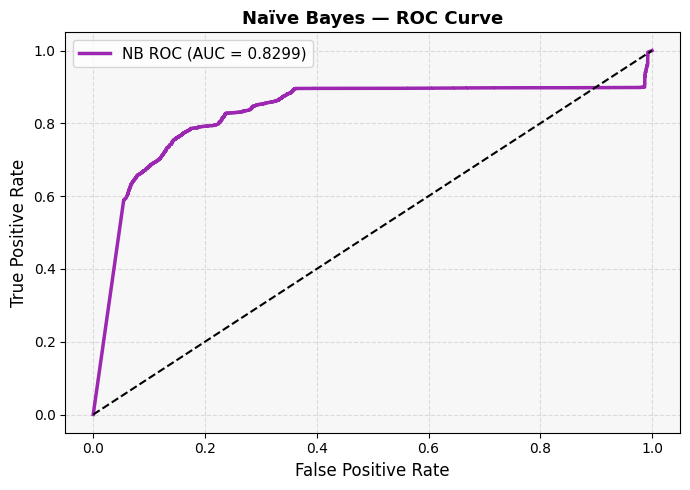

✅ Plot 6 saved

✅✅ ALL NAÏVE BAYES PLOTS SAVED! ✅✅


In [1]:
# ================================================================
#  STEP 1: INSTALL & IMPORTS
# ================================================================
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             precision_recall_fscore_support,
                             roc_curve, auc)

# ================================================================
#  STEP 2: DOWNLOAD DATASET
# ================================================================
!wget -q "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt" -O KDDTrain.txt
!wget -q "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt" -O KDDTest.txt
print("✅ Dataset downloaded!")

# ================================================================
#  STEP 3: LOAD & PREPROCESS
# ================================================================
cols = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

train_df = pd.read_csv('KDDTrain.txt', names=cols)
test_df  = pd.read_csv('KDDTest.txt',  names=cols)

train_df['label'] = (train_df['label'] != 'normal').astype(int)
test_df['label']  = (test_df['label']  != 'normal').astype(int)
train_df.drop(columns=['difficulty'], inplace=True)
test_df.drop(columns=['difficulty'],  inplace=True)

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[col], test_df[col]]))
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

X_train = train_df.drop(columns=['label']).values.astype(np.float32)
y_train = train_df['label'].values
X_test  = test_df.drop(columns=['label']).values.astype(np.float32)
y_test  = test_df['label'].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(f"✅ Data ready | Train: {X_train.shape} | Test: {X_test.shape}")

# ================================================================
#  STEP 4: TRAIN NAÏVE BAYES
# ================================================================
nb = GaussianNB()
nb.fit(X_train, y_train)
print("✅ Naïve Bayes Training complete!")

# ================================================================
#  STEP 5: EVALUATE
# ================================================================
y_pred      = nb.predict(X_test)
y_pred_prob = nb.predict_proba(X_test)[:,1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"\n{'='*45}")
print(f"  NAÏVE BAYES RESULTS")
print(f"{'='*45}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(classification_report(y_test, y_pred,
      target_names=['Normal','Attack']))

prec_cls, rec_cls, f1_cls, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=[0,1])
classes = ['Normal', 'Attack']

# ================================================================
#  STEP 6: ALL PLOTS
# ================================================================

# ── PLOT 1: Accuracy Bar ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(['Naïve Bayes'], [acc], color='#9C27B0',
       width=0.35, edgecolor='white')
ax.text(0, acc+0.005, f'{acc:.4f}', ha='center', va='bottom',
        fontsize=13, fontweight='bold')
ax.set_title('Naïve Bayes — Accuracy', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=12); ax.set_ylim(0.5, 1.08)
ax.grid(axis='y', alpha=0.4, linestyle='--'); ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('NB_01_Accuracy.png', dpi=200, bbox_inches='tight')
plt.show(); print("✅ Plot 1 saved")

# ── PLOT 2: Precision Bar ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, prec_cls, color=['#9C27B0','#E91E63'],
              width=0.4, edgecolor='white')
for bar, v in zip(bars, prec_cls):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Naïve Bayes — Precision', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12); ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.4, linestyle='--'); ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('NB_02_Precision.png', dpi=200, bbox_inches='tight')
plt.show(); print("✅ Plot 2 saved")

# ── PLOT 3: Recall Bar ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, rec_cls, color=['#9C27B0','#E91E63'],
              width=0.4, edgecolor='white')
for bar, v in zip(bars, rec_cls):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Naïve Bayes — Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Recall', fontsize=12); ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.4, linestyle='--'); ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('NB_03_Recall.png', dpi=200, bbox_inches='tight')
plt.show(); print("✅ Plot 3 saved")

# ── PLOT 4: F1-Score Bar ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, f1_cls, color=['#9C27B0','#E91E63'],
              width=0.4, edgecolor='white')
for bar, v in zip(bars, f1_cls):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Naïve Bayes — F1-Score', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12); ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.4, linestyle='--'); ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('NB_04_F1Score.png', dpi=200, bbox_inches='tight')
plt.show(); print("✅ Plot 4 saved")

# ── PLOT 5: Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'],
            annot_kws={"size":14,"weight":"bold"})
ax.set_title('Naïve Bayes — Confusion Matrix',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('NB_05_Confusion_Matrix.png', dpi=200, bbox_inches='tight')
plt.show(); print("✅ Plot 5 saved")

# ── PLOT 6: ROC Curve ────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#9C27B0', lw=2.5,
        label=f'NB ROC (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Naïve Bayes — ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.4, linestyle='--')
ax.set_facecolor('#f7f7f7')
plt.tight_layout()
plt.savefig('NB_06_ROC_Curve.png', dpi=200, bbox_inches='tight')
plt.show(); print("✅ Plot 6 saved")

print("\n✅✅ ALL NAÏVE BAYES PLOTS SAVED! ✅✅")